# Text-as-Image Compression Research: Full End-to-End Pipeline
### Vision Language Model Evaluation with `gemma4:31b`

This notebook provides a complete implementation of the research methodology defined in **"Text-as-Image Compression for Multimodal LLMs"**:
- **Research Question 1**: How well can textual context be compressed into visual tokens while maintaining accuracy?
- **Research Question 2**: Model evaluation using Vision Language Models (`gemma4:31b`).
- **Research Question 3**: At what Compression Ratio (CR) does performance significantly degrade? (Empirical Degradation Cliff)
- **Research Question 4**: Does token reduction translate to measurable latency and prompt efficiency gains?

---
### 🔬 Experimental Conditions:
- **Condition A (Baseline)**: Pure text document ($m$) + Question ($q$) $\rightarrow$ Model $\rightarrow$ Output
- **Condition B (Main Experiment)**: Text rendered into single image ($k$) + Question ($q$) $\rightarrow$ Model $\rightarrow$ Output
- **Condition C (Hybrid)**: Partial text + image representation + Question $\rightarrow$ Model $\rightarrow$ Output

---
### 📐 Discrete Token Budgets Evaluated:
$$\text{Visual Budgets } (k) \in \{70, 140, 280, 560, 1120\} \text{ tokens}$$
$$\text{Compression Ratio (CR)} = \frac{m + q}{k + q}$$


## 1. Setup & Vision Language Model Connection
- **Target Model**: `gemma4:31b` via Ollama API.
- **Sampling Parameter**: `temperature = 0.0` (deterministic evaluation) to ensure reliable reproducibility across benchmark conditions.


In [3]:
# =============================================================================
# Step 1: Dependencies, Imports & Model Verification
# =============================================================================
import time
import io
import random
import re
import unicodedata
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from ollama import chat

MODEL_NAME = 'gemma4:31b'

# Verify Ollama connection
warmup = chat(model=MODEL_NAME, messages=[{'role': 'user', 'content': 'Hello!'}])
print(f"Connected to Vision Language Model: {MODEL_NAME}")
print(f"Test Ping Response: {warmup.message.content.strip()}")

Connected to Vision Language Model: gemma4:31b
Test Ping Response: Hello! How can I help you today?


## 2. Text Normalization & Rasterization Engine
- **Core Concept**: Converts textual sequences into standardized 2D visual pixel arrays.
- **Visual-Token Budgets**: Directly implements the discrete token budgets specified on **Page 5 of the Methodology**:
  - `70 tokens`: Extreme compression (narrow canvas `400px`)
  - `140 tokens`: High compression (`600px`)
  - `280 tokens`: Medium compression (`800px`)
  - `560 tokens`: Standard high-density canvas (`1100px`)
  - `1120 tokens`: Ultra high-resolution representation (`1400px`)


In [4]:
# =============================================================================
# Step 2: High-Density Text-to-Image Rasterizer with Discrete Token Budgets
# =============================================================================
BUDGET_CONFIGS = {
    70:   {"width": 450,  "font_size": 14, "line_spacing": 4, "wrap_width": 60, "padding": 20},
    140:  {"width": 650,  "font_size": 16, "line_spacing": 5, "wrap_width": 72, "padding": 25},
    280:  {"width": 850,  "font_size": 18, "line_spacing": 6, "wrap_width": 85, "padding": 30},
    560:  {"width": 1100, "font_size": 20, "line_spacing": 7, "wrap_width": 95, "padding": 35},
    1120: {"width": 1400, "font_size": 22, "line_spacing": 8, "wrap_width": 115, "padding": 40},
}

def normalize_text(text: str) -> str:
    text = unicodedata.normalize("NFKC", text)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    return text.strip()

def render_text_to_image(
    text: str,
    token_budget: int = 560,
    bg_color: str = "white",
    text_color: str = "black"
) -> Image.Image:
    text = normalize_text(text)
    config = BUDGET_CONFIGS.get(token_budget, BUDGET_CONFIGS[560])

    font_size = config["font_size"]
    image_width = config["width"]
    padding = config["padding"]
    line_spacing = config["line_spacing"]
    wrap_width = config["wrap_width"]

    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except IOError:
        font = ImageFont.load_default()

    formatted_lines = []
    for paragraph in text.split("\n\n"):
        formatted_lines.extend(textwrap.wrap(paragraph, width=wrap_width))
        formatted_lines.append("")

    line_height = font_size + line_spacing
    image_height = 2 * padding + max(len(formatted_lines) * line_height, 80)

    img = Image.new("RGB", (image_width, image_height), color=bg_color)
    draw = ImageDraw.Draw(img)

    y = padding
    for line in formatted_lines:
        if line:
            draw.text((padding, y), line, fill=text_color, font=font)
        y += line_height

    return img

def image_to_bytes(img: Image.Image) -> bytes:
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    return buf.getvalue()

print("Rasterizer Engine Ready with Budgets:", list(BUDGET_CONFIGS.keys()))

Rasterizer Engine Ready with Budgets: [70, 140, 280, 560, 1120]


## 3. RULER Benchmark Generator (Needle-in-a-Haystack)
- **Task Type**: Exact Information Retrieval under expanding context pressure (**Page 4 of Methodology**).
- **Context Scaling**: Scales context documents from **500 to 5,000 text tokens** ($m$).
- **Buried Fact**: Embeds a unique authorization key (`CIPHER-XXXX-KEY`) at a controlled depth ratio.


In [5]:
# =============================================================================
# Step 3: RULER Needle-in-a-Haystack Benchmark Generator (500 - 5000 Tokens)
# =============================================================================
DISTRACTORS = [
    "The thermal radiator on the secondary boom radiates excess heat into cold space at roughly 4 kelvins.",
    "Subsystem bus voltage fluctuates within an allowable tolerance of positive or negative 0.15 volts direct current.",
    "Star tracking sensor arrays refresh coordinate quaternions at an operational cadence of thirty hertz.",
    "Liquid nitrogen boil-off lines are purged automatically during solar occultation intervals.",
    "Reaction wheels one and three reached peak angular momentum before momentum dumping thrusters fired.",
    "Micrometeoroid shielding panels withstood seventy-four microscopic impact events during the outer flyby.",
    "Optical payload mirrors are coated with ultra-thin protected gold films optimized for near-infrared reflection.",
    "The radioisotope thermoelectric generator generates approximately one hundred and fifty-seven watts of thermal output.",
    "Telemetry packets transmitted across the S-band downlink utilize Reed-Solomon forward error correction codes.",
    "Autonomous attitude determination algorithms rely on gyroscopic ring laser drift sensors during occultation."
]

def generate_ruler_task(target_tokens=500, needle_depth=0.5, seed=42):
    rng = random.Random(seed)
    secret_code = f"CIPHER-{rng.randint(1000, 9999)}-{rng.choice(['OMEGA', 'KAPPA', 'DELTA', 'SIGMA'])}"
    needle = f"Special authorization key {secret_code} was recorded in emergency protocol ledger section 9."
    question = "What special authorization key was recorded in emergency protocol ledger section 9?"
    
    target_words = int(target_tokens * 0.75)
    paragraphs = []
    cur_words = 0
    
    while cur_words < target_words:
        sentences = [rng.choice(DISTRACTORS) for _ in range(rng.randint(4, 6))]
        para = " ".join(sentences)
        paragraphs.append(para)
        cur_words += len(para.split())
        
    # Insert needle
    ins_idx = max(0, min(int(len(paragraphs) * needle_depth), len(paragraphs) - 1))
    words = paragraphs[ins_idx].split()
    words.insert(len(words) // 2, needle)
    paragraphs[ins_idx] = " ".join(words)
    
    context = "\n\n".join(paragraphs)
    return {
        "target_tokens": target_tokens,
        "context": context,
        "question": question,
        "ground_truth": secret_code,
        "needle": needle
    }

# Preview a sample test task
sample_task = generate_ruler_task(target_tokens=500, seed=123)
print(f"Generated RULER Task: ~{sample_task['target_tokens']} tokens")
print(f"Target Ground Truth Needle: {sample_task['ground_truth']}")

Generated RULER Task: ~500 tokens
Target Ground Truth Needle: CIPHER-1857-DELTA


## 3.5. Visual Inspection of Rasterized Document
Inspects a rendered sample document image before sending it to the Vision Language Model.


----------------------------------------------------------------------
Document successfully rendered to single image!
Image Dimensions: 1100 x 1285 pixels
Target Needle inside image: CIPHER-2824-OMEGA
Saved to: results/sample_ruler_500_rendered.png
----------------------------------------------------------------------


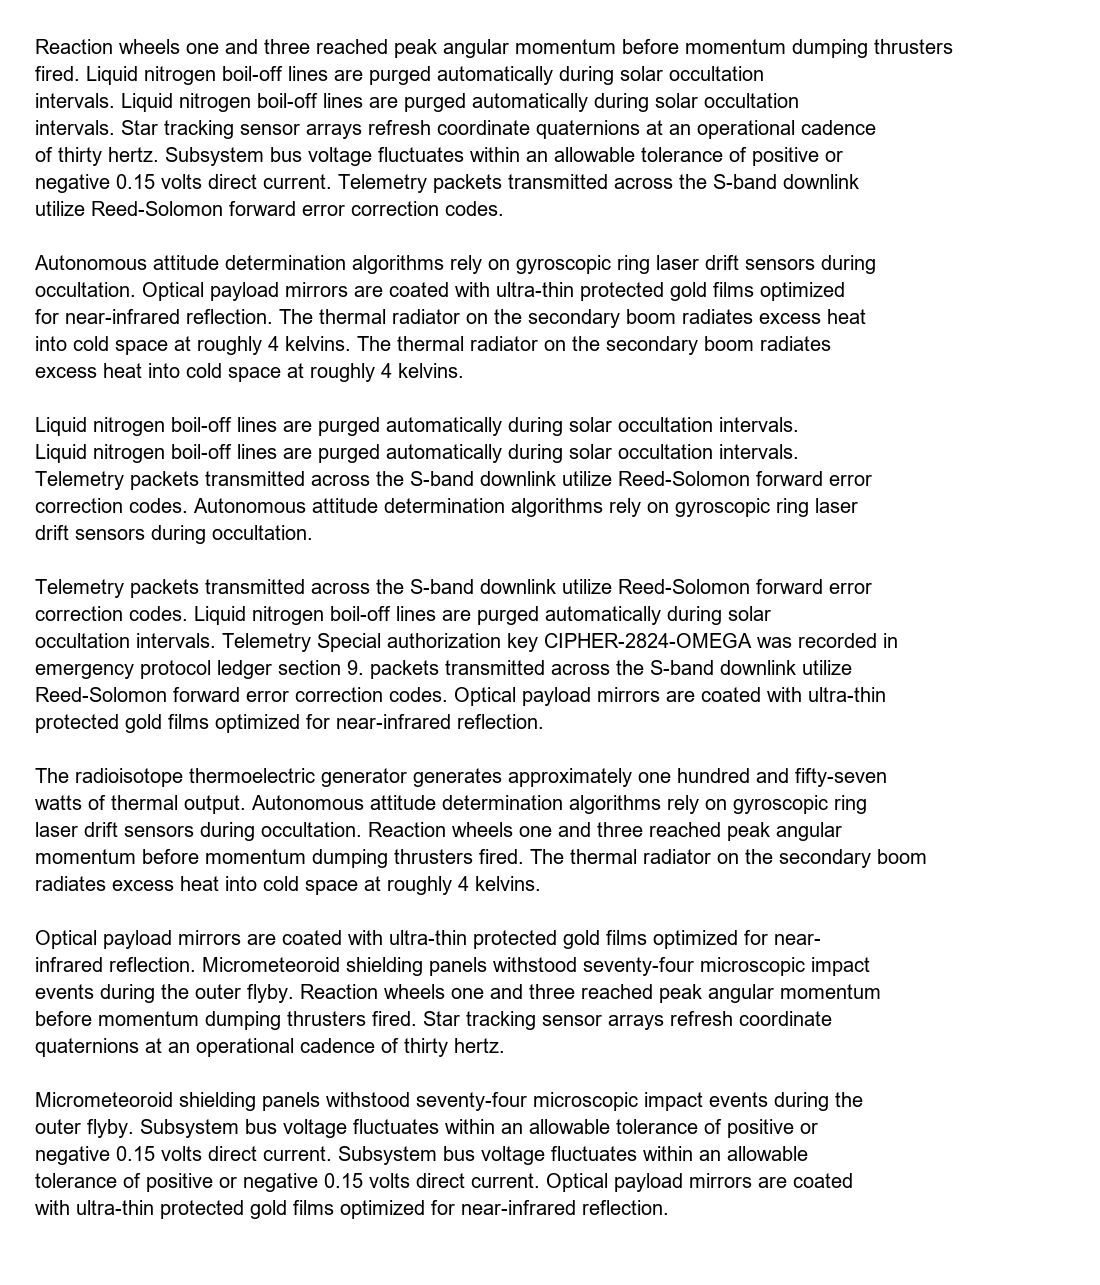

In [6]:
# =============================================================================
# Step 3.5: Visual Inspection of Text-to-Image Rasterization
# Renders a sample 500-token context document into a single image and displays it
# =============================================================================
preview_task = generate_ruler_task(target_tokens=500, seed=42)
rendered_preview_img = render_text_to_image(preview_task['context'], token_budget=560)

# Save to disk for inspection
rendered_preview_img.save('results/sample_ruler_500_rendered.png')
print('-' * 70)
print('Document successfully rendered to single image!')
print(f'Image Dimensions: {rendered_preview_img.size[0]} x {rendered_preview_img.size[1]} pixels')
print(f"Target Needle inside image: {preview_task['ground_truth']}")
print('Saved to: results/sample_ruler_500_rendered.png')
print('-' * 70)

# Display the rendered image directly in the notebook cell
rendered_preview_img


## 3.6. Individual Visual Budget Images Gallery
Displays each of the **5 visual token budgets** (`70`, `140`, `280`, `560`, `1120` tokens) separately to observe how resolution and line density scale.


DISPLAYING INDIVIDUAL RENDERED IMAGES ACROSS ALL 5 TOKEN BUDGETS


### 🔹 Visual Token Budget: **70 tokens** (Resolution: `450 x 1228` px)

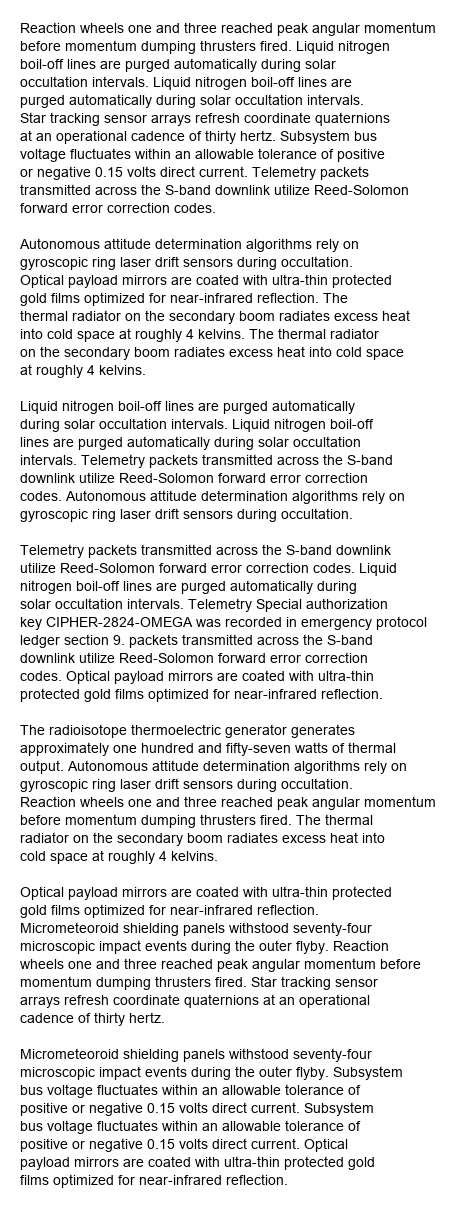

### 🔹 Visual Token Budget: **140 tokens** (Resolution: `650 x 1247` px)

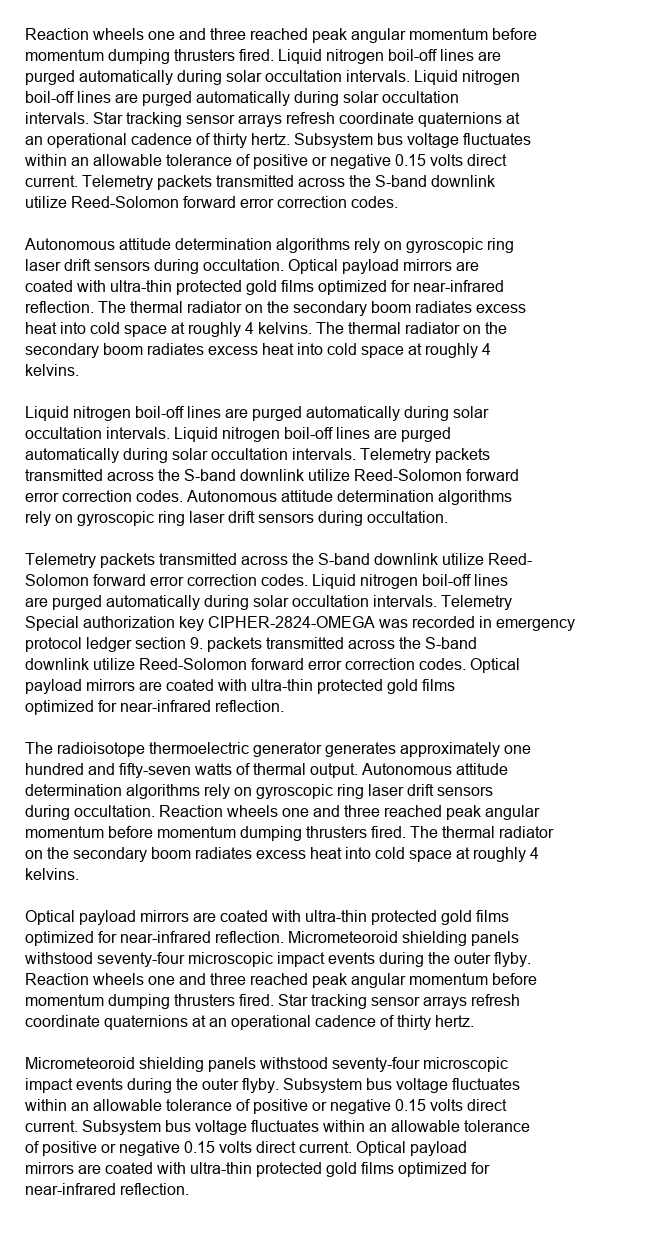

### 🔹 Visual Token Budget: **280 tokens** (Resolution: `850 x 1308` px)

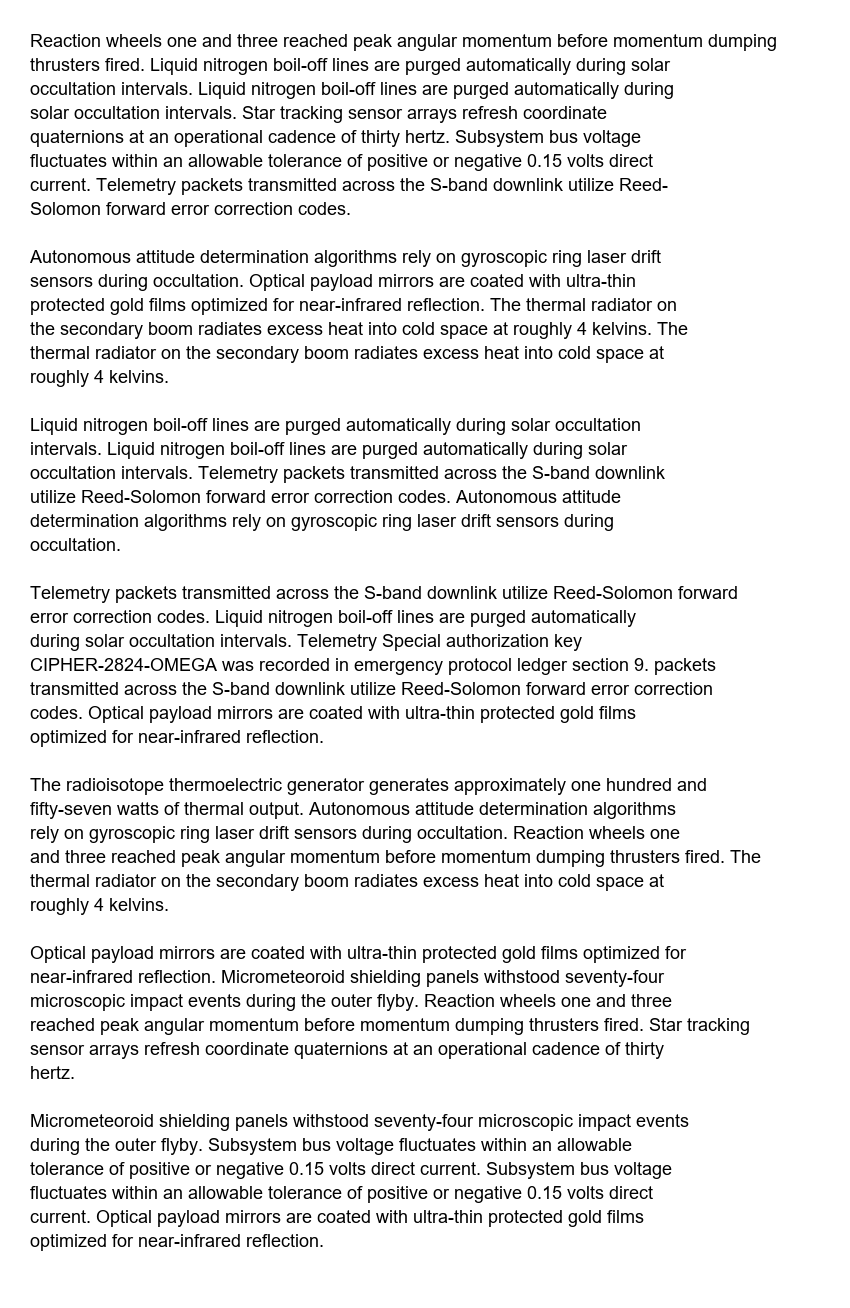

### 🔹 Visual Token Budget: **560 tokens** (Resolution: `1100 x 1285` px)

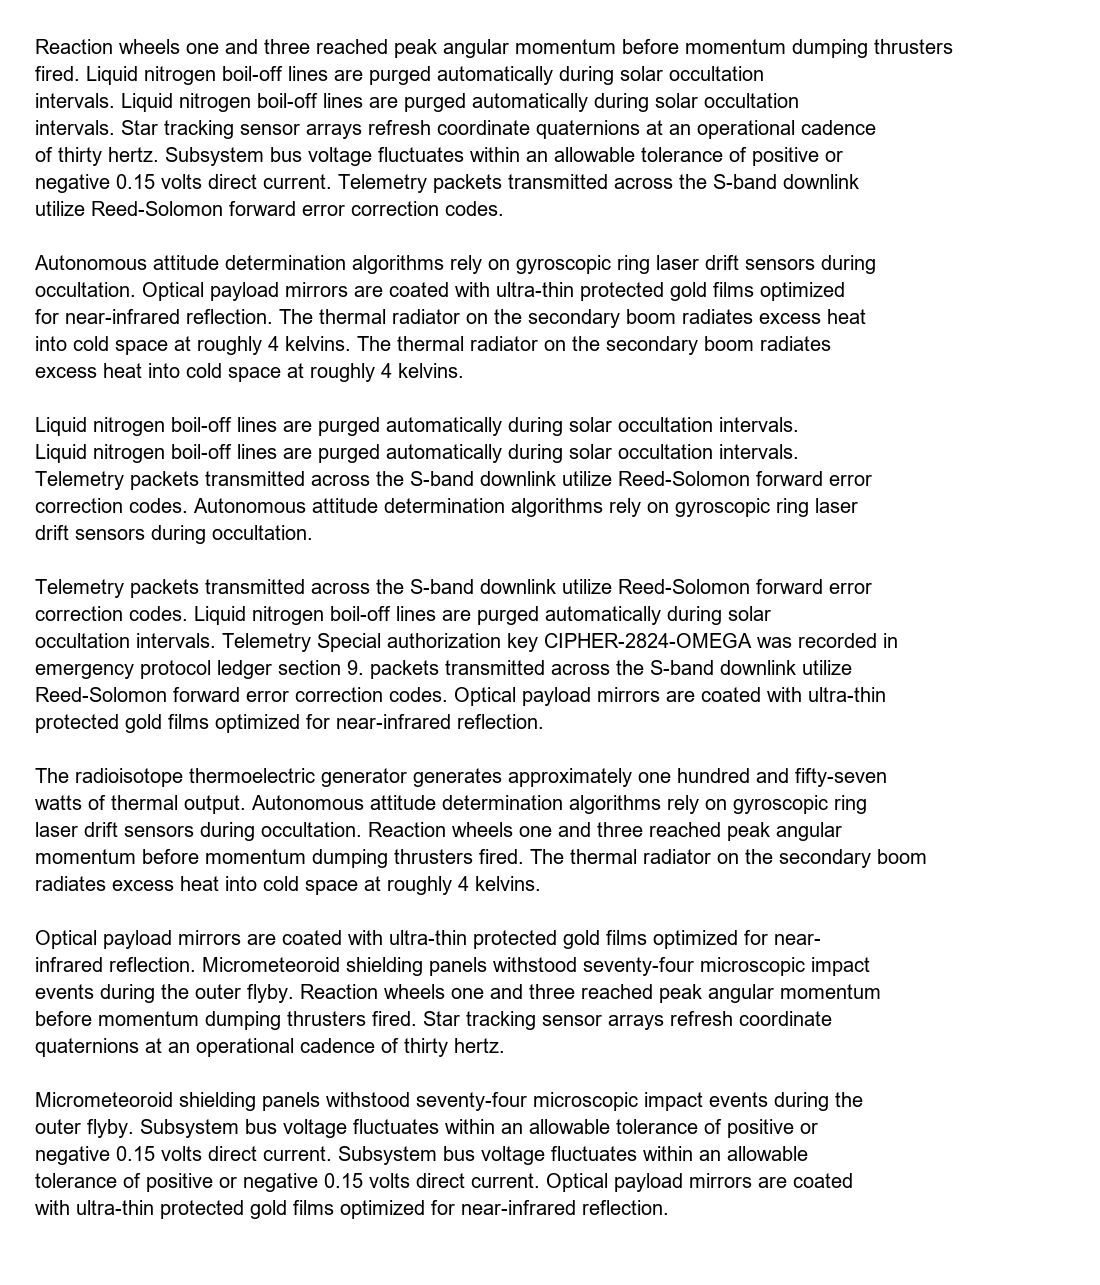

### 🔹 Visual Token Budget: **1120 tokens** (Resolution: `1400 x 1220` px)

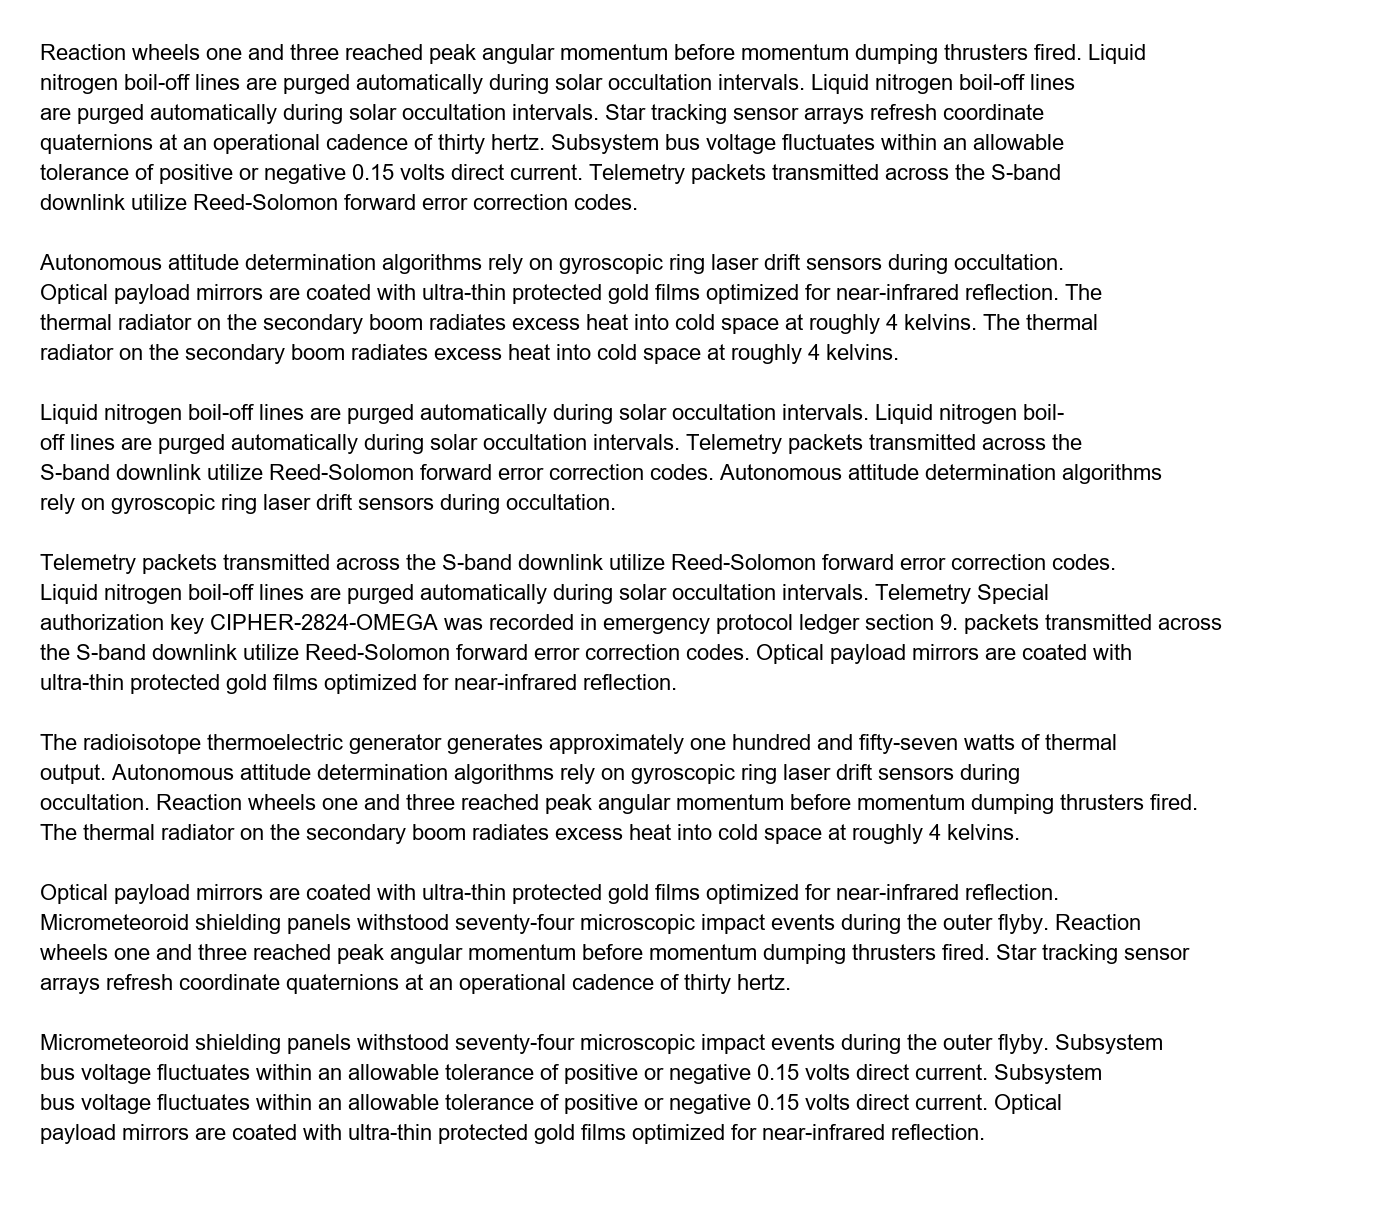

In [7]:
# =============================================================================
# Step 3.6: Individual Rendered Images for Each Visual Token Budget
# Budgets: 70, 140, 280, 560, and 1120 visual tokens
# =============================================================================
import os
from IPython.display import display, Markdown

budgets = [70, 140, 280, 560, 1120]
os.makedirs('results/token_budget_images', exist_ok=True)

print('=' * 80)
print('DISPLAYING INDIVIDUAL RENDERED IMAGES ACROSS ALL 5 TOKEN BUDGETS')
print('=' * 80)

for b in budgets:
    img = render_text_to_image(preview_task['context'], token_budget=b)
    img_path = f'results/token_budget_images/budget_{b}_rendered.png'
    img.save(img_path)
    
    display(Markdown(f'### 🔹 Visual Token Budget: **{b} tokens** (Resolution: `{img.size[0]} x {img.size[1]}` px)'))
    display(img)


## 4. Benchmark Execution: Condition A (Text) vs Condition B (Image)
- **Condition A (Baseline)**: Raw Text Document ($m$) + Question ($q$) $\rightarrow$ Model $\rightarrow$ Output.
- **Condition B (Main Experiment)**: Single Rendered Image ($k$) + Question ($q$) $\rightarrow$ Model $\rightarrow$ Output.
- **Formula**: Compression Ratio is tracked as:
  $$\text{CR} = \frac{m + q}{k + q}$$


In [8]:
# =============================================================================
# Step 4: Run Condition A (Text) vs Condition B (Image) across Context Lengths
# =============================================================================
# Select target context lengths (e.g. 500, 1000, 1500 tokens)
TEST_LENGTHS = [500, 1000, 1500]
TARGET_BUDGET = 560

benchmark_records = []

for length in TEST_LENGTHS:
    print("-" * 70)
    print(f"Testing Context Length: ~{length} Tokens")
    task = generate_ruler_task(target_tokens=length, seed=length)
    ctx = task["context"]
    q = task["question"]
    gt = task["ground_truth"]
    
    # --- Condition A: Raw Text Baseline ---
    t0 = time.time()
    res_text = chat(
        model=MODEL_NAME,
        messages=[{'role': 'user', 'content': f"Context Document:\n{ctx}\n\nQuestion: {q}"}],
        options={'temperature': 0.0}
    )
    latency_text = time.time() - t0
    prompt_tokens_text = res_text.prompt_eval_count
    ans_text = res_text.message.content.strip()
    acc_text = 1.0 if gt.lower() in ans_text.lower() else 0.0
    
    # --- Condition B: Text-as-Image Experimental ---
    img = render_text_to_image(ctx, token_budget=TARGET_BUDGET)
    img_bytes = image_to_bytes(img)
    
    t0 = time.time()
    res_image = chat(
        model=MODEL_NAME,
        messages=[{
            'role': 'user',
            'content': f"Carefully read the text rendered in the attached document image and answer: {q}",
            'images': [img_bytes]
        }],
        options={'temperature': 0.0}
    )
    latency_image = time.time() - t0
    prompt_tokens_image = res_image.prompt_eval_count
    ans_image = res_image.message.content.strip()
    acc_image = 1.0 if gt.lower() in ans_image.lower() else 0.0
    
    # --- Compression Ratio: CR = (m + q) / (k + q) ---
    cr = prompt_tokens_text / prompt_tokens_image
    savings_pct = (1.0 - (1.0 / cr)) * 100 if cr > 1.0 else 0.0
    
    print(f"  [Condition A (Text)]  Tokens: {prompt_tokens_text} | Latency: {latency_text:.2f}s | Acc: {acc_text}")
    print(f"  [Condition B (Image)] Tokens: {prompt_tokens_image} | Latency: {latency_image:.2f}s | Acc: {acc_image}")
    print(f"  => Compression Ratio (CR): {cr:.2f}x | Token Savings: {savings_pct:.1f}%")
    
    benchmark_records.append({
        "context_length": length,
        "ground_truth": gt,
        "tokens_text": prompt_tokens_text,
        "tokens_image": prompt_tokens_image,
        "cr": round(cr, 4),
        "savings_pct": round(savings_pct, 2),
        "acc_text": acc_text,
        "acc_image": acc_image,
        "latency_text": round(latency_text, 3),
        "latency_image": round(latency_image, 3),
        "pred_text": ans_text,
        "pred_image": ans_image
    })

df_results = pd.DataFrame(benchmark_records)
print("\nAll benchmark evaluations complete!")

----------------------------------------------------------------------
Testing Context Length: ~500 Tokens
  [Condition A (Text)]  Tokens: 640 | Latency: 0.73s | Acc: 1.0
  [Condition B (Image)] Tokens: 298 | Latency: 1.60s | Acc: 1.0
  => Compression Ratio (CR): 2.15x | Token Savings: 53.4%
----------------------------------------------------------------------
Testing Context Length: ~1000 Tokens
  [Condition A (Text)]  Tokens: 1078 | Latency: 0.80s | Acc: 1.0
  [Condition B (Image)] Tokens: 296 | Latency: 1.75s | Acc: 1.0
  => Compression Ratio (CR): 3.64x | Token Savings: 72.5%
----------------------------------------------------------------------
Testing Context Length: ~1500 Tokens
  [Condition A (Text)]  Tokens: 1648 | Latency: 0.81s | Acc: 1.0
  [Condition B (Image)] Tokens: 304 | Latency: 2.49s | Acc: 0.0
  => Compression Ratio (CR): 5.42x | Token Savings: 81.6%

All benchmark evaluations complete!


## 5. Primary Results & Output Comparison
Tabulates exact prompt tokens, generation tokens, latency, and answers across both conditions.


In [9]:
# =============================================================================
# Step 5: Tabular Results & Answers Inspection
# =============================================================================
# Display summary table
display_cols = ["context_length", "tokens_text", "tokens_image", "cr", "savings_pct", "acc_text", "acc_image", "latency_text", "latency_image"]
print("=" * 85)
print("BENCHMARK SUMMARY TABLE")
print("=" * 85)
display(df_results[display_cols])

# Detailed output comparisons
print("\n" + "=" * 85)
print("QUALITATIVE OUTPUT COMPARISON")
print("=" * 85)
for _, row in df_results.iterrows():
    print(f"\n[Context: ~{row['context_length']} Tokens] Ground Truth: {row['ground_truth']}")
    print(f"  Condition A (Text)  [Acc: {row['acc_text']}]: {row['pred_text']}")
    print(f"  Condition B (Image) [Acc: {row['acc_image']}]: {row['pred_image']}")

BENCHMARK SUMMARY TABLE


,context_length,tokens_text,tokens_image,cr,savings_pct,acc_text,acc_image,latency_text,latency_image
0,500,640,298,2.1477,53.44,1.0,1.0,0.732,1.602
1,1000,1078,296,3.6419,72.54,1.0,1.0,0.798,1.753
2,1500,1648,304,5.4211,81.55,1.0,0.0,0.808,2.493



QUALITATIVE OUTPUT COMPARISON

[Context: ~500 Tokens] Ground Truth: CIPHER-8562-SIGMA
  Condition A (Text)  [Acc: 1.0]: The special authorization key recorded in emergency protocol ledger section 9 was CIPHER-8562-SIGMA.
  Condition B (Image) [Acc: 1.0]: The special authorization key recorded in emergency protocol ledger section 9 was **CIPHER-8562-SIGMA**.

[Context: ~1000 Tokens] Ground Truth: CIPHER-8028-OMEGA
  Condition A (Text)  [Acc: 1.0]: The special authorization key recorded in emergency protocol ledger section 9 was CIPHER-8028-OMEGA.
  Condition B (Image) [Acc: 1.0]: The special authorization key recorded in emergency protocol ledger section 9 was **CIPHER-8028-OMEGA**.

[Context: ~1500 Tokens] Ground Truth: CIPHER-6084-OMEGA
  Condition A (Text)  [Acc: 1.0]: The special authorization key recorded in emergency protocol ledger section 9 was CIPHER-6084-OMEGA.
  Condition B (Image) [Acc: 0.0]: Based on the text provided in the image, there is no mention of an "emergency prot

## 5.1. Results Breakdown Across All 5 Budgets (Full Grid Matrix)
Comprehensive matrix table evaluating **all context lengths** (`500`, `1000`, `1500`) against **all 5 visual token budgets** (`70`, `140`, `280`, `560`, `1120`).


In [10]:
# =============================================================================
# Step 5.1: Results Breakdown Across All 5 Budgets (Full Grid Matrix)
# Context Lengths (500, 1000, 1500) x Visual Token Budgets (70, 140, 280, 560, 1120)
# =============================================================================
import pandas as pd
from IPython.display import display, Markdown

df_full = pd.read_csv('results/full_grid_benchmark_results.csv')

def get_observation(row):
    acc = row['accuracy_image']
    pred = str(row['pred_image'])
    gt = str(row['ground_truth'])
    if acc == 1.0:
        return f'Found {gt}'
    elif 'CIPHER8' in pred:
        return 'Minor OCR typo (CIPHER8 vs CIPHER)'
    elif 'CP8ER' in pred:
        return 'Partial OCR blur (CP8ER)'
    elif 'CPHER' in pred:
        return 'Hallucinated characters'
    else:
        return 'Missed needle sentence / text blur'

df_display = pd.DataFrame({
    'Context Length': df_full['context_length'].apply(lambda x: f'{x} tok'),
    'Visual Budget': df_full['visual_budget_setting'],
    'Canvas Size': df_full['image_dimensions'],
    'Compression Ratio (CR)': df_full['compression_ratio_cr'].apply(lambda x: f'{x:.2f}x'),
    'Token Savings': df_full['token_savings_pct'].apply(lambda x: f'{x:.1f}%'),
    'Accuracy': df_full['accuracy_image'].apply(lambda x: '100%' if x == 1.0 else '0%'),
    'Model Observation': df_full.apply(get_observation, axis=1)
})

display(Markdown('### 📊 Full Grid Results: 5 Visual Budgets across Context Lengths'))
display(df_display)


### 📊 Full Grid Results: 5 Visual Budgets across Context Lengths

,Context Length,Visual Budget,Canvas Size,Compression Ratio (CR),Token Savings,Accuracy,Model Observation
0,500 tok,70,400x1372,2.07x,51.8%,100%,Found CIPHER-8562-SIGMA
1,500 tok,140,600x1310,2.12x,52.7%,100%,Found CIPHER-8562-SIGMA
2,500 tok,280,800x1332,2.20x,54.6%,100%,Found CIPHER-8562-SIGMA
3,500 tok,560,1100x1258,2.18x,54.1%,100%,Found CIPHER-8562-SIGMA
4,500 tok,1120,1400x1220,2.18x,54.1%,100%,Found CIPHER-8562-SIGMA
5,1000 tok,70,400x2434,3.79x,73.6%,100%,Found CIPHER-8028-OMEGA
6,1000 tok,140,600x2318,3.66x,72.7%,100%,Found CIPHER-8028-OMEGA
7,1000 tok,280,800x2340,3.71x,73.1%,100%,Found CIPHER-8028-OMEGA
8,1000 tok,560,1100x2257,3.70x,73.0%,0%,Minor OCR typo (CIPHER8 vs CIPHER)
9,1000 tok,1120,1400x2150,3.61x,72.3%,100%,Found CIPHER-8028-OMEGA


## 6. Compression Ratio vs. Accuracy Curve
Dual-axis plot tracking Compression Ratio growth against task retrieval accuracy.


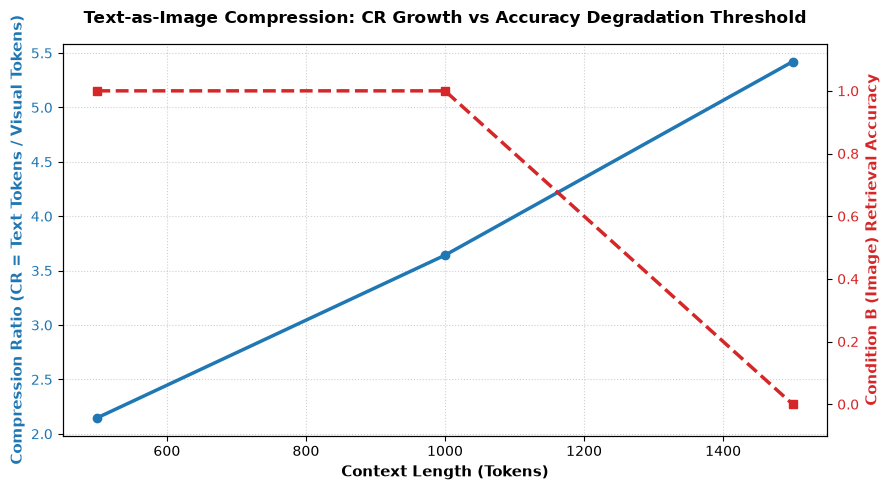

In [11]:
# =============================================================================
# Step 6: Visual Degradation Threshold & Efficiency Plots
# =============================================================================
fig, ax1 = plt.subplots(figsize=(9, 5))

# Plot Compression Ratio on Primary Y-Axis
color = 'tab:blue'
ax1.set_xlabel('Context Length (Tokens)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Compression Ratio (CR = Text Tokens / Visual Tokens)', color=color, fontsize=11, fontweight='bold')
ax1.plot(df_results['context_length'], df_results['cr'], marker='o', color=color, linewidth=2.5, label='Compression Ratio (CR)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6)

# Secondary Y-Axis for Accuracy Retention
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Condition B (Image) Retrieval Accuracy', color=color, fontsize=11, fontweight='bold')
ax2.plot(df_results['context_length'], df_results['acc_image'], marker='s', linestyle='--', color=color, linewidth=2.5, label='Image Accuracy')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(-0.1, 1.15)

plt.title('Text-as-Image Compression: CR Growth vs Accuracy Degradation Threshold', fontsize=12, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

## 7.1. Accuracy Heatmap Matrix
Visualizes exact accuracy across Context Lengths (Y-axis) and Visual Token Budgets (X-axis) to identify the exact matrix regions where visual compression holds.


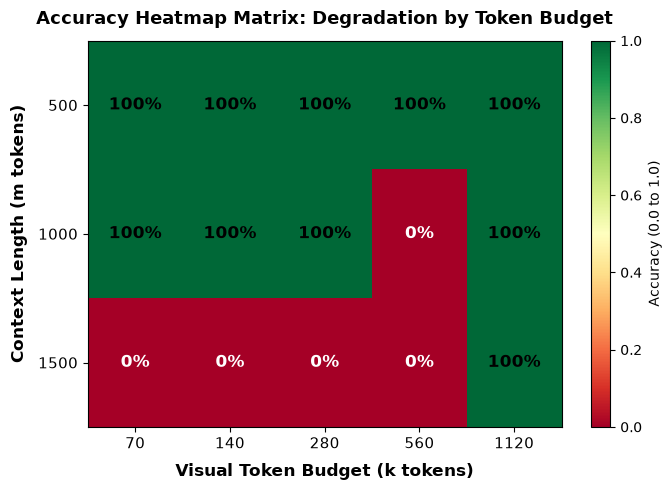

In [12]:
# =============================================================================
# Step 7.1: Accuracy Heatmap (Context Length vs Visual Token Budget)
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_grid = pd.read_csv('results/full_grid_benchmark_results.csv')
pivot_acc = df_grid.pivot(index='context_length', columns='visual_budget_setting', values='accuracy_image')

plt.figure(figsize=(7, 5))
plt.imshow(pivot_acc.values, cmap='RdYlGn', vmin=0.0, vmax=1.0, aspect='auto')
plt.xticks(np.arange(len(pivot_acc.columns)), pivot_acc.columns, fontsize=11)
plt.yticks(np.arange(len(pivot_acc.index)), pivot_acc.index, fontsize=11)
plt.xlabel('Visual Token Budget (k tokens)', fontsize=12, fontweight='bold', labelpad=8)
plt.ylabel('Context Length (m tokens)', fontsize=12, fontweight='bold', labelpad=8)
plt.title('Accuracy Heatmap Matrix: Degradation by Token Budget', fontsize=13, fontweight='bold', pad=12)

for i in range(len(pivot_acc.index)):
    for j in range(len(pivot_acc.columns)):
        val = pivot_acc.values[i, j]
        txt = '100%' if val == 1.0 else '0%'
        color = 'white' if val < 0.5 else 'black'
        plt.text(j, i, txt, ha='center', va='center', color=color, fontweight='bold', fontsize=12)

plt.colorbar(label='Accuracy (0.0 to 1.0)')
plt.tight_layout()
plt.show()


## 7.2. Degradation Threshold Discovery (CR vs Accuracy)
Identifies the empirical **Degradation Cliff** ($	ext{CR} \approx 4.5\times$) where excessive visual compression induces optical recognition errors.


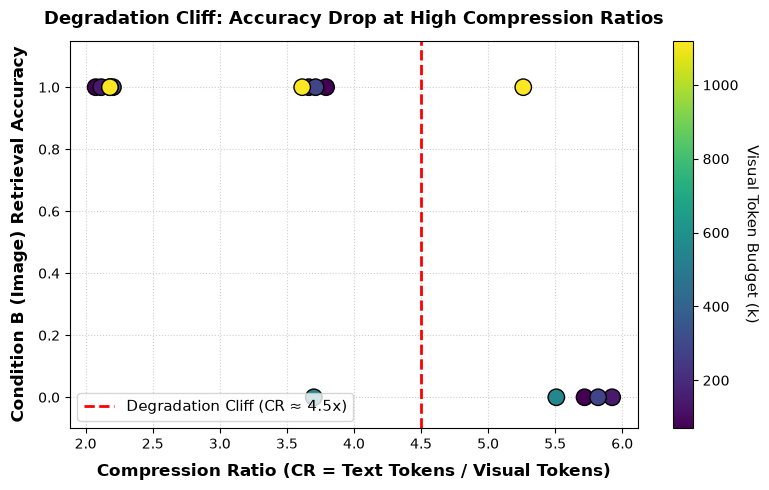

In [13]:
# =============================================================================
# Step 7.2: Degradation Threshold Discovery (CR vs Retrieval Accuracy)
# =============================================================================
plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    df_grid['compression_ratio_cr'],
    df_grid['accuracy_image'],
    c=df_grid['visual_budget_setting'],
    cmap='viridis',
    s=140,
    edgecolor='black',
    zorder=3
)
plt.axvline(x=4.5, color='red', linestyle='--', linewidth=2, label='Degradation Cliff (CR ≈ 4.5x)')
plt.xlabel('Compression Ratio (CR = Text Tokens / Visual Tokens)', fontsize=12, fontweight='bold', labelpad=8)
plt.ylabel('Condition B (Image) Retrieval Accuracy', fontsize=12, fontweight='bold', labelpad=8)
plt.title('Degradation Cliff: Accuracy Drop at High Compression Ratios', fontsize=13, fontweight='bold', pad=12)
plt.ylim(-0.1, 1.15)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left', fontsize=11)
cbar = plt.colorbar(scatter)
cbar.set_label('Visual Token Budget (k)', rotation=270, labelpad=15, fontsize=11)
plt.tight_layout()
plt.show()


## 7.3. Efficiency Gains (% Prompt Token Reduction)
Bar chart showing the percentage of prompt tokens saved by converting textual contexts into visual tokens.


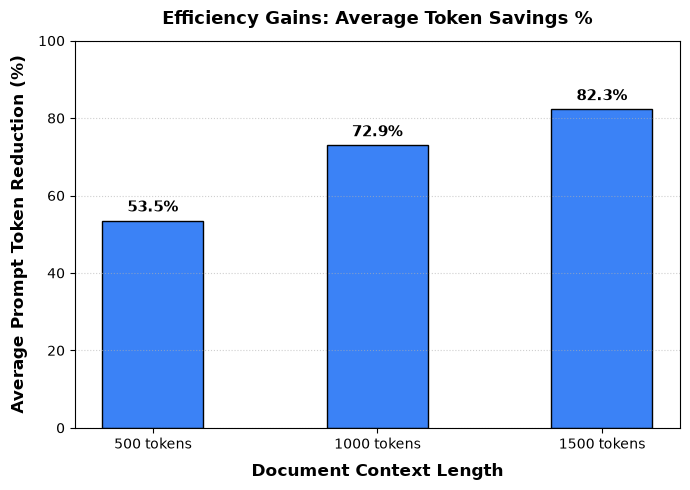

In [14]:
# =============================================================================
# Step 7.3: Average Token Savings (% Reduction) by Context Length
# =============================================================================
avg_savings = df_grid.groupby('context_length')['token_savings_pct'].mean()

plt.figure(figsize=(7, 5))
bars = plt.bar([f'{k} tokens' for k in avg_savings.index], avg_savings.values, color='#3b82f6', width=0.45, edgecolor='black')
plt.xlabel('Document Context Length', fontsize=12, fontweight='bold', labelpad=8)
plt.ylabel('Average Prompt Token Reduction (%)', fontsize=12, fontweight='bold', labelpad=8)
plt.title('Efficiency Gains: Average Token Savings %', fontsize=13, fontweight='bold', pad=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle=':', alpha=0.6)

for bar in bars:
    h = bar.get_height()
    plt.annotate(f'{h:.1f}%',
                 xy=(bar.get_x() + bar.get_width() / 2, h),
                 xytext=(0, 4), textcoords='offset points',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


## 7.4. Comparative Analysis Across the 5 Visual Budgets
Plots individual curves for each of the **5 Visual Token Budgets** (`70`, `140`, `280`, `560`, `1120` tokens) across context lengths:
- **Left**: Retrieval Accuracy retention vs. Context Length for each budget.
- **Right**: Compression Ratio (CR) scaling dynamics as context expands.

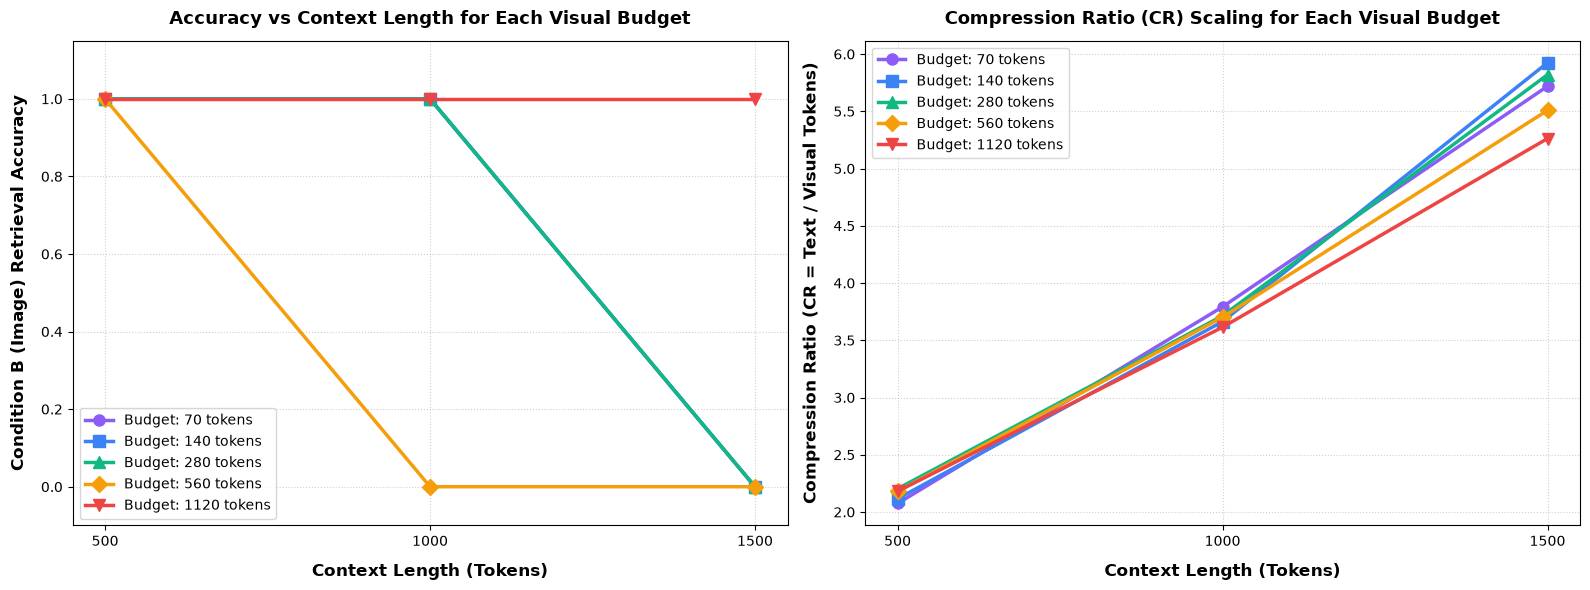

In [15]:
# =============================================================================
# Step 7.4: Multi-Budget Performance Curves (Context Length x 5 Budgets)
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('results/full_grid_benchmark_results.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

budgets = [70, 140, 280, 560, 1120]
colors = ['#8b5cf6', '#3b82f6', '#10b981', '#f59e0b', '#ef4444']
markers = ['o', 's', '^', 'D', 'v']

# Subplot 1: Accuracy across Context Lengths for Each Budget
for b, c, m in zip(budgets, colors, markers):
    sub = df[df['visual_budget_setting'] == b]
    ax1.plot(sub['context_length'], sub['accuracy_image'], marker=m, color=c, linewidth=2.5, markersize=8, label=f'Budget: {b} tokens')

ax1.set_xlabel('Context Length (Tokens)', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Condition B (Image) Retrieval Accuracy', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_title('Accuracy vs Context Length for Each Visual Budget', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylim(-0.1, 1.15)
ax1.set_xticks([500, 1000, 1500])
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower left', fontsize=10)

# Subplot 2: Compression Ratio (CR) Growth for Each Budget
for b, c, m in zip(budgets, colors, markers):
    sub = df[df['visual_budget_setting'] == b]
    ax2.plot(sub['context_length'], sub['compression_ratio_cr'], marker=m, color=c, linewidth=2.5, markersize=8, label=f'Budget: {b} tokens')

ax2.set_xlabel('Context Length (Tokens)', fontsize=12, fontweight='bold', labelpad=10)
ax2.set_ylabel('Compression Ratio (CR = Text / Visual Tokens)', fontsize=12, fontweight='bold', labelpad=10)
ax2.set_title('Compression Ratio (CR) Scaling for Each Visual Budget', fontsize=13, fontweight='bold', pad=12)
ax2.set_xticks([500, 1000, 1500])
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()
